# CAT 2 — CUDA Image Processing Pipeline (Colab T4)

Same 5 filters as the C codebase, accelerated on a CUDA GPU. Two blur kernels (naive vs. tiled with shared memory) demonstrate the GPU programming depth move. `cudaEvent` profiling separates H2D / kernel / D2H so we can see exactly where the GPU pays off.

**Before running**, in Colab: `Runtime → Change runtime type → GPU` (T4 is fine).


In [ ]:
# 1. Confirm GPU
!nvidia-smi --query-gpu=name,driver_version,memory.total --format=csv,noheader
!nvcc --version | tail -1


Tesla T4, 580.82.07, 15360 MiB
Build cuda_12.8.r12.8/compiler.35583870_0


In [ ]:
# 2. Setup project layout, fetch stb_image headers (single-header public-domain image I/O)
import os, urllib.request, pathlib
for d in ["kernels", "data/reference", "results"]:
    pathlib.Path(d).mkdir(parents=True, exist_ok=True)

stb_base = "https://raw.githubusercontent.com/nothings/stb/master/"
for h in ["stb_image.h", "stb_image_write.h"]:
    if not os.path.exists(f"kernels/{h}"):
        urllib.request.urlretrieve(stb_base + h, f"kernels/{h}")
print("kernels/:", os.listdir("kernels"))


kernels/: ['stb_image.h', 'stb_image_write.h']


## Upload data
Upload `input.jpg` and the 5 sequential reference outputs (`out_blur.png`, `out_sobel.png`, `out_sharp.png`, `out_bc.png`, `out_histeq.png`) from your local `data/reference/` directory.


In [ ]:
# 3. Upload input.jpg + reference PNGs
from google.colab import files
import shutil, os
print("Select: input.jpg + out_blur.png, out_sobel.png, out_sharp.png, out_bc.png, out_histeq.png")
uploaded = files.upload()
for fn in list(uploaded):
    if fn.startswith("out_"):
        shutil.move(fn, f"data/reference/{fn}")
print("\ndata/reference/ →", sorted(os.listdir("data/reference")))
print("input.jpg present:", os.path.exists("input.jpg"))


Select: input.jpg + out_blur.png, out_sobel.png, out_sharp.png, out_bc.png, out_histeq.png


Saving input.jpg to input.jpg
Saving out_bc.png to out_bc.png
Saving out_blur.png to out_blur.png
Saving out_histeq.png to out_histeq.png
Saving out_sharp.png to out_sharp.png
Saving out_sobel.png to out_sobel.png

data/reference/ → ['out_bc.png', 'out_blur.png', 'out_histeq.png', 'out_sharp.png', 'out_sobel.png']
input.jpg present: True


In [ ]:
%%writefile cuda_pipeline.cu
#include <cuda_runtime.h>
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>

#define STB_IMAGE_IMPLEMENTATION
#define STBI_NO_HDR
#define STBI_NO_LINEAR
#include "kernels/stb_image.h"
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "kernels/stb_image_write.h"

#define CUDA_CHECK(call) do { cudaError_t e = (call); if (e != cudaSuccess) { \
    fprintf(stderr, "CUDA error %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(e)); \
    exit(1); } } while (0)

#define BLOCK 16
#define HALO_BLUR  2
#define TILE_BLUR  (BLOCK + 2 * HALO_BLUR)
#define HALO_SOBEL 1
#define TILE_SOBEL (BLOCK + 2 * HALO_SOBEL)

__constant__ float c_G5[5][5];

__device__ __forceinline__ int mirror_idx(int i, int n) {
    if (i < 0) return -i;
    if (i >= n) return 2 * n - i - 2;
    return i;
}

/* ---------- Blur: naive ---------- */
__global__ void blur_naive_kernel(const unsigned char* __restrict__ src,
                                  unsigned char* __restrict__ dst,
                                  int W, int H) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x >= W || y >= H) return;
    float acc = 0.f;
    #pragma unroll
    for (int ky = -2; ky <= 2; ky++) {
        int yy = mirror_idx(y + ky, H);
        #pragma unroll
        for (int kx = -2; kx <= 2; kx++) {
            int xx = mirror_idx(x + kx, W);
            acc += (float)src[yy * W + xx] * c_G5[ky + 2][kx + 2];
        }
    }
    int v = (int)(acc + 0.5f);
    dst[y * W + x] = (unsigned char)max(0, min(255, v));
}

/* ---------- Blur: tiled with shared memory ---------- */
__global__ void blur_tiled_kernel(const unsigned char* __restrict__ src,
                                  unsigned char* __restrict__ dst,
                                  int W, int H) {
    __shared__ unsigned char tile[TILE_BLUR][TILE_BLUR];
    int tx = threadIdx.x, ty = threadIdx.y;
    int x0 = blockIdx.x * BLOCK;
    int y0 = blockIdx.y * BLOCK;

    int tid = ty * BLOCK + tx;
    int total = BLOCK * BLOCK;
    int loads = TILE_BLUR * TILE_BLUR;
    for (int i = tid; i < loads; i += total) {
        int dy = i / TILE_BLUR;
        int dx = i % TILE_BLUR;
        int gx = mirror_idx(x0 + dx - HALO_BLUR, W);
        int gy = mirror_idx(y0 + dy - HALO_BLUR, H);
        tile[dy][dx] = src[gy * W + gx];
    }
    __syncthreads();

    int x = x0 + tx, y = y0 + ty;
    if (x >= W || y >= H) return;
    float acc = 0.f;
    #pragma unroll
    for (int ky = 0; ky < 5; ky++)
        #pragma unroll
        for (int kx = 0; kx < 5; kx++)
            acc += (float)tile[ty + ky][tx + kx] * c_G5[ky][kx];
    int v = (int)(acc + 0.5f);
    dst[y * W + x] = (unsigned char)max(0, min(255, v));
}

/* ---------- Sobel: tiled compute, atomic-max for normalisation ---------- */
__global__ void sobel_compute_kernel(const unsigned char* __restrict__ src,
                                     float* __restrict__ mag,
                                     unsigned int* __restrict__ g_max_u,
                                     int W, int H) {
    __shared__ unsigned char tile[TILE_SOBEL][TILE_SOBEL];
    int tx = threadIdx.x, ty = threadIdx.y;
    int x0 = blockIdx.x * BLOCK;
    int y0 = blockIdx.y * BLOCK;

    int tid = ty * BLOCK + tx;
    int total = BLOCK * BLOCK;
    int loads = TILE_SOBEL * TILE_SOBEL;
    for (int i = tid; i < loads; i += total) {
        int dy = i / TILE_SOBEL;
        int dx = i % TILE_SOBEL;
        int gx = mirror_idx(x0 + dx - HALO_SOBEL, W);
        int gy = mirror_idx(y0 + dy - HALO_SOBEL, H);
        tile[dy][dx] = src[gy * W + gx];
    }
    __syncthreads();

    int x = x0 + tx, y = y0 + ty;
    if (x >= W || y >= H) return;
    float a00=tile[ty][tx],   a01=tile[ty][tx+1],   a02=tile[ty][tx+2];
    float a10=tile[ty+1][tx], /*ctr*/                a12=tile[ty+1][tx+2];
    float a20=tile[ty+2][tx], a21=tile[ty+2][tx+1], a22=tile[ty+2][tx+2];
    float gx = (-a00 + a02) + (-2.f*a10 + 2.f*a12) + (-a20 + a22);
    float gy = ( a00 + 2.f*a01 + a02) - (a20 + 2.f*a21 + a22);
    float m = sqrtf(gx*gx + gy*gy);
    mag[y * W + x] = m;
    /* For non-negative floats, IEEE-754 bit pattern ordering matches numerical order. */
    atomicMax(g_max_u, __float_as_uint(m));
}

__global__ void sobel_normalize_kernel(const float* __restrict__ mag,
                                       unsigned char* __restrict__ dst,
                                       int N, float scale) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= N) return;
    int v = (int)(mag[i] * scale + 0.5f);
    dst[i] = (unsigned char)max(0, min(255, v));
}

/* ---------- Brightness/contrast: pointwise ---------- */
__global__ void bc_kernel(const unsigned char* __restrict__ src,
                          unsigned char* __restrict__ dst,
                          int N, float brightness, float contrast) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= N) return;
    float v = ((float)src[i] - 128.f) * contrast + 128.f + brightness + 0.5f;
    int iv = (int)v;
    dst[i] = (unsigned char)max(0, min(255, iv));
}

/* ---------- Unsharp combine ---------- */
__global__ void unsharp_combine_kernel(const unsigned char* __restrict__ src,
                                       const unsigned char* __restrict__ blurred,
                                       unsigned char* __restrict__ dst,
                                       int N, float amount) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= N) return;
    int s = src[i], b = blurred[i];
    float v = (float)s + amount * (float)(s - b) + 0.5f;
    int iv = (int)v;
    dst[i] = (unsigned char)max(0, min(255, iv));
}

/* ---------- Histogram: shared-memory atomic reduction ---------- */
__global__ void hist_kernel(const unsigned char* __restrict__ src,
                            unsigned int* __restrict__ g_hist,
                            int N) {
    __shared__ unsigned int s_hist[256];
    int tid = threadIdx.x;
    if (tid < 256) s_hist[tid] = 0;
    __syncthreads();

    int i = blockIdx.x * blockDim.x + tid;
    int stride = gridDim.x * blockDim.x;
    while (i < N) {
        atomicAdd(&s_hist[src[i]], 1u);
        i += stride;
    }
    __syncthreads();

    if (tid < 256) atomicAdd(&g_hist[tid], s_hist[tid]);
}

__global__ void apply_lut_kernel(const unsigned char* __restrict__ src,
                                 unsigned char* __restrict__ dst,
                                 int N,
                                 const unsigned char* __restrict__ lut) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= N) return;
    dst[i] = lut[src[i]];
}

/* ---------- Host helpers ---------- */
static void hist_to_lut(const unsigned int hist[256], int total, unsigned char lut[256]) {
    unsigned int cdf[256];
    cdf[0] = hist[0];
    for (int i = 1; i < 256; i++) cdf[i] = cdf[i-1] + hist[i];
    unsigned int cdf_min = 0;
    for (int i = 0; i < 256; i++) { if (cdf[i] != 0) { cdf_min = cdf[i]; break; } }
    unsigned int denom = (unsigned int)total - cdf_min;
    if (denom == 0) denom = 1;
    for (int i = 0; i < 256; i++) {
        if (cdf[i] < cdf_min) lut[i] = 0;
        else lut[i] = (unsigned char)(((float)(cdf[i] - cdf_min) / denom) * 255.f + 0.5f);
    }
}

/* Constant Gaussian 5x5 kernel (sigma~1) */
static const float h_G5[5][5] = {
    {1.f/256, 4.f/256,  6.f/256, 4.f/256, 1.f/256},
    {4.f/256,16.f/256, 24.f/256,16.f/256, 4.f/256},
    {6.f/256,24.f/256, 36.f/256,24.f/256, 6.f/256},
    {4.f/256,16.f/256, 24.f/256,16.f/256, 4.f/256},
    {1.f/256, 4.f/256,  6.f/256, 4.f/256, 1.f/256}
};

/* Run the chosen filter end-to-end with cudaEvent timing.
   For warmup runs we discard timings; for timed runs we accumulate. */
typedef void (*launch_fn)(const unsigned char* d_src, unsigned char* d_dst, int W, int H);

static void launch_blur_naive(const unsigned char* d_src, unsigned char* d_dst, int W, int H) {
    dim3 block(BLOCK, BLOCK);
    dim3 grid((W + BLOCK - 1) / BLOCK, (H + BLOCK - 1) / BLOCK);
    blur_naive_kernel<<<grid, block>>>(d_src, d_dst, W, H);
}
static void launch_blur_tiled(const unsigned char* d_src, unsigned char* d_dst, int W, int H) {
    dim3 block(BLOCK, BLOCK);
    dim3 grid((W + BLOCK - 1) / BLOCK, (H + BLOCK - 1) / BLOCK);
    blur_tiled_kernel<<<grid, block>>>(d_src, d_dst, W, H);
}

static void launch_sobel(const unsigned char* d_src, unsigned char* d_dst, int W, int H) {
    int N = W * H;
    float* d_mag = nullptr;
    unsigned int* d_max_u = nullptr;
    CUDA_CHECK(cudaMalloc(&d_mag, (size_t)N * sizeof(float)));
    CUDA_CHECK(cudaMalloc(&d_max_u, sizeof(unsigned int)));
    CUDA_CHECK(cudaMemset(d_max_u, 0, sizeof(unsigned int)));

    dim3 block(BLOCK, BLOCK);
    dim3 grid((W + BLOCK - 1) / BLOCK, (H + BLOCK - 1) / BLOCK);
    sobel_compute_kernel<<<grid, block>>>(d_src, d_mag, d_max_u, W, H);

    unsigned int h_max_u = 0;
    CUDA_CHECK(cudaMemcpy(&h_max_u, d_max_u, sizeof(unsigned int), cudaMemcpyDeviceToHost));
    float h_max;
    memcpy(&h_max, &h_max_u, sizeof(float));
    float scale = (h_max > 0.f) ? (255.f / h_max) : 1.f;

    int threads = 256;
    int blocks = (N + threads - 1) / threads;
    sobel_normalize_kernel<<<blocks, threads>>>(d_mag, d_dst, N, scale);

    cudaFree(d_mag);
    cudaFree(d_max_u);
}

static void launch_sharp(const unsigned char* d_src, unsigned char* d_dst, int W, int H) {
    int N = W * H;
    unsigned char* d_blurred = nullptr;
    CUDA_CHECK(cudaMalloc(&d_blurred, N));
    dim3 block(BLOCK, BLOCK);
    dim3 grid((W + BLOCK - 1) / BLOCK, (H + BLOCK - 1) / BLOCK);
    blur_tiled_kernel<<<grid, block>>>(d_src, d_blurred, W, H);
    int threads = 256;
    int blocks = (N + threads - 1) / threads;
    unsharp_combine_kernel<<<blocks, threads>>>(d_src, d_blurred, d_dst, N, 1.0f);
    cudaFree(d_blurred);
}

static void launch_bc(const unsigned char* d_src, unsigned char* d_dst, int W, int H) {
    int N = W * H;
    int threads = 256;
    int blocks = (N + threads - 1) / threads;
    bc_kernel<<<blocks, threads>>>(d_src, d_dst, N, 20.0f, 1.2f);
}

static void launch_histeq(const unsigned char* d_src, unsigned char* d_dst, int W, int H) {
    int N = W * H;
    unsigned int* d_hist = nullptr;
    CUDA_CHECK(cudaMalloc(&d_hist, 256 * sizeof(unsigned int)));
    CUDA_CHECK(cudaMemset(d_hist, 0, 256 * sizeof(unsigned int)));

    int threads = 256;
    int blocks = (N + threads - 1) / threads;
    if (blocks > 4096) blocks = 4096;  /* cap grid; loop inside kernel covers the rest */
    hist_kernel<<<blocks, threads>>>(d_src, d_hist, N);

    unsigned int h_hist[256];
    CUDA_CHECK(cudaMemcpy(h_hist, d_hist, 256 * sizeof(unsigned int), cudaMemcpyDeviceToHost));
    unsigned char h_lut[256];
    hist_to_lut(h_hist, N, h_lut);
    unsigned char* d_lut = nullptr;
    CUDA_CHECK(cudaMalloc(&d_lut, 256));
    CUDA_CHECK(cudaMemcpy(d_lut, h_lut, 256, cudaMemcpyHostToDevice));

    int t2 = 256;
    int b2 = (N + t2 - 1) / t2;
    apply_lut_kernel<<<b2, t2>>>(d_src, d_dst, N, d_lut);

    cudaFree(d_hist);
    cudaFree(d_lut);
}

static int run_filter(const char* name, const unsigned char* h_src, unsigned char* h_dst,
                      int W, int H, int warmup, int timed, FILE* csvf) {
    launch_fn fn = nullptr;
    if      (strcmp(name, "blur_naive") == 0) fn = launch_blur_naive;
    else if (strcmp(name, "blur_tiled") == 0 || strcmp(name, "blur") == 0) fn = launch_blur_tiled;
    else if (strcmp(name, "sobel")  == 0) fn = launch_sobel;
    else if (strcmp(name, "sharp")  == 0) fn = launch_sharp;
    else if (strcmp(name, "bc")     == 0) fn = launch_bc;
    else if (strcmp(name, "histeq") == 0) fn = launch_histeq;
    else { fprintf(stderr, "unknown filter: %s\n", name); return 1; }

    int N = W * H;
    unsigned char *d_src = nullptr, *d_dst = nullptr;
    CUDA_CHECK(cudaMalloc(&d_src, N));
    CUDA_CHECK(cudaMalloc(&d_dst, N));
    CUDA_CHECK(cudaMemcpyToSymbol(c_G5, h_G5, sizeof(h_G5)));

    cudaEvent_t e0, e1, e2, e3;
    cudaEventCreate(&e0); cudaEventCreate(&e1);
    cudaEventCreate(&e2); cudaEventCreate(&e3);

    for (int w = 0; w < warmup; w++) {
        cudaMemcpy(d_src, h_src, N, cudaMemcpyHostToDevice);
        fn(d_src, d_dst, W, H);
        cudaMemcpy(h_dst, d_dst, N, cudaMemcpyDeviceToHost);
    }

    double sum_h2d = 0, sum_k = 0, sum_d2h = 0;
    for (int t = 0; t < timed; t++) {
        cudaEventRecord(e0);
        cudaMemcpy(d_src, h_src, N, cudaMemcpyHostToDevice);
        cudaEventRecord(e1);
        fn(d_src, d_dst, W, H);
        cudaEventRecord(e2);
        cudaMemcpy(h_dst, d_dst, N, cudaMemcpyDeviceToHost);
        cudaEventRecord(e3);
        CUDA_CHECK(cudaEventSynchronize(e3));
        float t_h2d, t_k, t_d2h;
        cudaEventElapsedTime(&t_h2d, e0, e1);
        cudaEventElapsedTime(&t_k,   e1, e2);
        cudaEventElapsedTime(&t_d2h, e2, e3);
        sum_h2d += t_h2d; sum_k += t_k; sum_d2h += t_d2h;
    }
    float mean_h2d = sum_h2d / timed;
    float mean_k   = sum_k   / timed;
    float mean_d2h = sum_d2h / timed;
    float mean_total = mean_h2d + mean_k + mean_d2h;

    printf("[cuda/%s] h2d=%.3fms kernel=%.3fms d2h=%.3fms total=%.3fms (warmup=%d, timed=%d)\n",
           name, mean_h2d, mean_k, mean_d2h, mean_total, warmup, timed);

    if (csvf) {
        fprintf(csvf, "cuda,%s,1,%d,%d,%d,%.6f,0,0,0,%d,%d,%.4f,%.4f,%.4f\n",
                name, W, H, N, mean_total / 1000.0, warmup, timed,
                mean_h2d, mean_k, mean_d2h);
    }

    cudaFree(d_src); cudaFree(d_dst);
    cudaEventDestroy(e0); cudaEventDestroy(e1);
    cudaEventDestroy(e2); cudaEventDestroy(e3);
    return 0;
}

int main(int argc, char** argv) {
    if (argc < 4) {
        fprintf(stderr, "Usage: %s <input> <filter|all> <output_prefix> [warmup=3] [timed=10] [csv]\n", argv[0]);
        fprintf(stderr, "  filters: blur_naive, blur_tiled (alias 'blur'), sobel, sharp, bc, histeq, all\n");
        return 1;
    }
    const char* in_path = argv[1];
    const char* fname   = argv[2];
    const char* prefix  = argv[3];
    int warmup = (argc > 4) ? atoi(argv[4]) : 3;
    int timed  = (argc > 5) ? atoi(argv[5]) : 10;
    const char* csv = (argc > 6 && argv[6][0]) ? argv[6] : nullptr;

    int w, h, n;
    unsigned char* h_src = stbi_load(in_path, &w, &h, &n, 1);
    if (!h_src) { fprintf(stderr, "load failed: %s\n", stbi_failure_reason()); return 2; }
    unsigned char* h_dst = (unsigned char*)malloc((size_t)w * h);

    int dev = 0; cudaSetDevice(dev);
    cudaDeviceProp prop; cudaGetDeviceProperties(&prop, dev);
    printf("GPU: %s (CC %d.%d, %.1f GB)\n", prop.name, prop.major, prop.minor,
           prop.totalGlobalMem / (1024.0*1024.0*1024.0));
    printf("Loaded %s: %dx%d (1 channel)\n", in_path, w, h);

    FILE* csvf = nullptr;
    if (csv) {
        FILE* probe = fopen(csv, "r");
        int new_file = (probe == nullptr);
        if (probe) fclose(probe);
        csvf = fopen(csv, "a");
        if (csvf && new_file) {
            fprintf(csvf, "paradigm,filter,threads,width,height,pixels,mean_s,stddev_s,min_s,max_s,warmup,timed,h2d_ms,kernel_ms,d2h_ms\n");
        }
    }

    const char* names[] = {"blur_naive","blur_tiled","sobel","sharp","bc","histeq", nullptr};
    int run_all = (strcmp(fname, "all") == 0);

    for (int i = 0; names[i]; i++) {
        if (!run_all && strcmp(fname, names[i]) != 0) continue;
        run_filter(names[i], h_src, h_dst, w, h, warmup, timed, csvf);

        char out_path[512];
        const char* dot = strrchr(prefix, '.');
        if (dot) {
            int blen = (int)(dot - prefix);
            snprintf(out_path, sizeof(out_path), "%.*s_%s%s", blen, prefix, names[i], dot);
        } else {
            snprintf(out_path, sizeof(out_path), "%s_%s.png", prefix, names[i]);
        }
        stbi_write_png(out_path, w, h, 1, h_dst, w);
        printf("  -> %s\n", out_path);
    }

    if (csvf) fclose(csvf);
    free(h_src); free(h_dst);
    return 0;
}


Writing cuda_pipeline.cu


In [ ]:
# 5. Compile with nvcc. -arch=sm_70 covers V100/T4/A100 (forward-compatible PTX).
import subprocess, sys
cmd = ["nvcc", "-O3", "-std=c++14", "-arch=sm_70", "cuda_pipeline.cu", "-o", "cuda_pipeline"]
print(" ".join(cmd))
r = subprocess.run(cmd, capture_output=True, text=True)
if r.stdout: print(r.stdout)
if r.stderr: print(r.stderr)
print("Exit:", r.returncode)
assert r.returncode == 0, "nvcc failed"


nvcc -O3 -std=c++14 -arch=sm_70 cuda_pipeline.cu -o cuda_pipeline
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
kernels/stb_image.h(4276): warning #550-D: variable "old_limit" was set but never used
     unsigned int cur, limit, old_limit;
                              ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

kernels/stb_image.h(5185): warning #550-D: variable "idata_limit_old" was set but never used
                 stbi__uint32 idata_limit_old = idata_limit;
                              ^

kernels/stb_image.h(6972): warning #550-D: variable "out_size" was set but never used
        int out_size = 0;
            ^

kernels/stb_image.h(6973): warning #550-D: variable "delays_size" was set but never used
        int delays_size = 0;
            ^


Exit: 0


In [ ]:
# 6. Run all 6 filter configs (blur_naive, blur_tiled, sobel, sharp, bc, histeq)
import subprocess
r = subprocess.run(["./cuda_pipeline", "input.jpg", "all", "results/cuda.png", "3", "10", "results/cuda.csv"],
                   capture_output=True, text=True)
print(r.stdout)
if r.stderr: print("STDERR:", r.stderr)


GPU: Tesla T4 (CC 7.5, 14.6 GB)
Loaded input.jpg: 6000x3376 (1 channel)
[cuda/blur_naive] h2d=3.974ms kernel=1.805ms d2h=4.045ms total=9.824ms (warmup=3, timed=10)
  -> results/cuda_blur_naive.png
[cuda/blur_tiled] h2d=4.074ms kernel=2.336ms d2h=4.118ms total=10.528ms (warmup=3, timed=10)
  -> results/cuda_blur_tiled.png
[cuda/sobel] h2d=4.053ms kernel=4.072ms d2h=4.015ms total=12.140ms (warmup=3, timed=10)
  -> results/cuda_sobel.png
[cuda/sharp] h2d=4.077ms kernel=2.747ms d2h=4.136ms total=10.960ms (warmup=3, timed=10)
  -> results/cuda_sharp.png
[cuda/bc] h2d=4.370ms kernel=0.646ms d2h=4.307ms total=9.323ms (warmup=3, timed=10)
  -> results/cuda_bc.png
[cuda/histeq] h2d=4.109ms kernel=1.270ms d2h=4.096ms total=9.475ms (warmup=3, timed=10)
  -> results/cuda_histeq.png



In [ ]:
# 7. Parse the breakdown CSV and show a tidy table
import pandas as pd
df = pd.read_csv("results/cuda.csv")
df["total_ms"] = df["mean_s"] * 1000.0
df = df[["filter", "h2d_ms", "kernel_ms", "d2h_ms", "total_ms"]].copy()
df = df.round({"h2d_ms": 3, "kernel_ms": 3, "d2h_ms": 3, "total_ms": 3})
df


,filter,h2d_ms,kernel_ms,d2h_ms,total_ms
0,blur_naive,3.974,1.805,4.045,9.824
1,blur_tiled,4.074,2.336,4.118,10.528
2,sobel,4.053,4.072,4.015,12.140
3,sharp,4.077,2.747,4.136,10.960
4,bc,4.370,0.646,4.307,9.323
5,histeq,4.109,1.270,4.096,9.475


Naive blur kernel : 1.805 ms
Tiled blur kernel : 2.336 ms
Tiled speedup     : 0.77x  (shared-memory tile reuse)


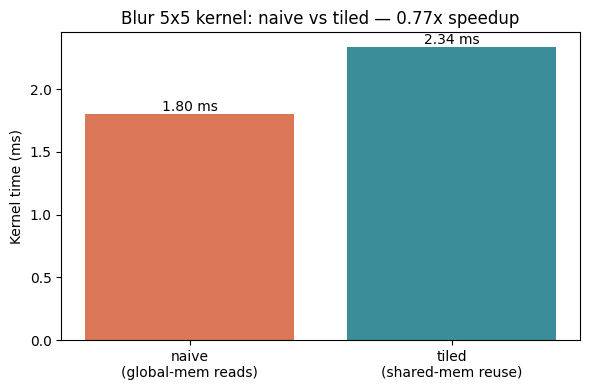

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 8. Naive vs tiled blur — the depth move
# The original error "KeyError: False" suggests that the boolean condition
# 'df.filter == "blur_naive"' might have unexpectedly evaluated to a scalar
# boolean 'False' instead of a boolean Series, causing pandas to attempt to
# index 'df' with a column named 'False', which does not exist.
#
# To address this, we will ensure that the selection always results in a DataFrame.
# We'll use .loc for explicit label-based indexing and add a check for an empty result.
selected_naive_rows = df.loc[df['filter'] == "blur_naive"]
if selected_naive_rows.empty:
    raise ValueError("No row found for filter 'blur_naive'. Check filter name or DataFrame content.")
naive = selected_naive_rows.iloc[0]

selected_tiled_rows = df.loc[df['filter'] == "blur_tiled"]
if selected_tiled_rows.empty:
    raise ValueError("No row found for filter 'blur_tiled'. Check filter name or DataFrame content.")
tiled = selected_tiled_rows.iloc[0]

speedup = naive.kernel_ms / tiled.kernel_ms
print(f"Naive blur kernel : {naive.kernel_ms:.3f} ms")
print(f"Tiled blur kernel : {tiled.kernel_ms:.3f} ms")
print(f"Tiled speedup     : {speedup:.2f}x  (shared-memory tile reuse)")

fig, ax = plt.subplots(figsize=(6,4))
labels = ["naive\n(global-mem reads)", "tiled\n(shared-mem reuse)"]
ax.bar(labels, [naive.kernel_ms, tiled.kernel_ms], color=["#d97757","#3a8d99"])
ax.set_ylabel("Kernel time (ms)")
ax.set_title(f"Blur 5x5 kernel: naive vs tiled — {speedup:.2f}x speedup")
for i, v in enumerate([naive.kernel_ms, tiled.kernel_ms]):
    ax.text(i, v, f"{v:.2f} ms", ha="center", va="bottom")
plt.tight_layout(); plt.show()


In [ ]:
# 9. PSNR validation against the C sequential reference outputs.
# CUDA is not bit-identical to seq (FP order on GPU differs); we use the same
# tolerance as bench/correctness.py: PSNR > 40 dB AND maxDiff <= 2.
import numpy as np
from PIL import Image

def psnr(a, b):
    a = a.astype(np.float64); b = b.astype(np.float64)
    mse = np.mean((a - b) ** 2)
    if mse == 0: return float("inf"), 0.0
    return 20.0 * np.log10(255.0 / np.sqrt(mse)), float(np.max(np.abs(a - b)))

# Map cuda filter names to the seq reference filename
ref_map = {
    "blur_naive": "blur", "blur_tiled": "blur",
    "sobel": "sobel", "sharp": "sharp",
    "bc": "bc", "histeq": "histeq",
}
print(f"{'cuda filter':<15s} {'PSNR(dB)':>10s} {'maxDiff':>8s}  status")
print("-" * 55)
all_ok = True
for fname, ref_name in ref_map.items():
    ref_path = f"data/reference/out_{ref_name}.png"
    cand_path = f"results/cuda_{fname}.png"
    try:
        ref = np.asarray(Image.open(ref_path).convert("L"))
        cand = np.asarray(Image.open(cand_path).convert("L"))
    except FileNotFoundError as e:
        print(f"{fname:<15s} missing: {e.filename}")
        all_ok = False
        continue
    p, mx = psnr(ref, cand)
    ok = (p > 40.0) and (mx <= 2.0)
    if not ok: all_ok = False
    ps = "inf" if p == float("inf") else f"{p:.2f}"
    tag = "OK" if ok else "FAIL"
    print(f"{fname:<15s} {ps:>10s} {mx:>8.1f}  {tag}")
print("-" * 55)
print("All within tolerance" if all_ok else "Some outputs exceed tolerance — check FP differences")


cuda filter       PSNR(dB)  maxDiff  status
-------------------------------------------------------
blur_naive             inf      0.0  OK
blur_tiled             inf      0.0  OK
sobel                  inf      0.0  OK
sharp                  inf      0.0  OK
bc                     inf      0.0  OK
histeq                 inf      0.0  OK
-------------------------------------------------------
All within tolerance


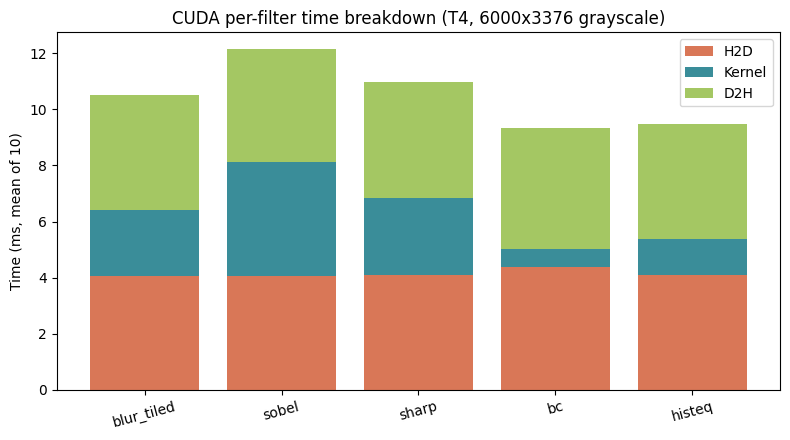


Observations to note for the report:
  blur_tiled    transfer =  77.8% of total  (kernel=2.34ms, H2D+D2H=8.19ms)
  sobel         transfer =  66.5% of total  (kernel=4.07ms, H2D+D2H=8.07ms)
  sharp         transfer =  74.9% of total  (kernel=2.75ms, H2D+D2H=8.21ms)
  bc            transfer =  93.1% of total  (kernel=0.65ms, H2D+D2H=8.68ms)
  histeq        transfer =  86.6% of total  (kernel=1.27ms, H2D+D2H=8.21ms)


In [ ]:
# 10. H2D / kernel / D2H breakdown — the GPU-economics chart
import matplotlib.pyplot as plt
import numpy as np

# Skip blur_naive in the breakdown chart (we keep blur_tiled as the canonical blur)
# Fix: Use df['filter'] instead of df.filter to explicitly access the column
# as 'filter' is also a method of pandas.DataFrame, which was causing the KeyError: True.
plot_df = df[df['filter'] != "blur_naive"].set_index("filter")
plot_df = plot_df.reindex(["blur_tiled", "sobel", "sharp", "bc", "histeq"])

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(plot_df))
ax.bar(x, plot_df.h2d_ms,    label="H2D",    color="#d97757")
ax.bar(x, plot_df.kernel_ms, bottom=plot_df.h2d_ms, label="Kernel", color="#3a8d99")
ax.bar(x, plot_df.d2h_ms,    bottom=plot_df.h2d_ms + plot_df.kernel_ms, label="D2H", color="#a4c763")
ax.set_xticks(x); ax.set_xticklabels(plot_df.index, rotation=15)
ax.set_ylabel("Time (ms, mean of 10)")
ax.set_title("CUDA per-filter time breakdown (T4, 6000x3376 grayscale)")
ax.legend()
plt.tight_layout(); plt.show()

print("\nObservations to note for the report:")
for f, row in plot_df.iterrows():
    transfer = row.h2d_ms + row.d2h_ms
    pct_transfer = 100 * transfer / (transfer + row.kernel_ms)
    print(f"  {f:<12s}  transfer = {pct_transfer:5.1f}% of total  (kernel={row.kernel_ms:.2f}ms, H2D+D2H={transfer:.2f}ms)")


## Download outputs back to local
The CUDA reference outputs (`results/cuda_*.png`) and the unified CSV (`results/cuda.csv`) can be downloaded back into the project's `results/` directory for the dashboard step.


In [ ]:
# 11. Zip outputs and download
!zip -j cuda_outputs.zip results/cuda*.png results/cuda.csv
from google.colab import files
files.download("cuda_outputs.zip")


  adding: cuda_bc.png (deflated 3%)
  adding: cuda_blur_naive.png (deflated 3%)
  adding: cuda_blur_tiled.png (deflated 3%)
  adding: cuda_histeq.png (deflated 2%)
  adding: cuda_sharp.png (deflated 3%)
  adding: cuda_sobel.png (deflated 3%)
  adding: cuda.csv (deflated 54%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>